# 💸 Financial Loss Analysis — Quantifying the Crisis Damage

This notebook calculates the **total financial impact** of the crisis by comparing actual performance against pre-crisis baselines:
- Revenue gap (actual vs expected)
- Cost of cancelled orders
- Customer lifetime value lost
- Restaurant revenue impact
- Delivery cost inefficiencies
- Total damage summary

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12})

PRE_COLOR = '#2ecc71'
CRISIS_COLOR = '#e74c3c'
EXPECTED_COLOR = '#3498db'
GAP_COLOR = '#f39c12'

In [2]:
def load_data(table):
    return pd.read_csv(f'rpc_18_inputs_for_participants//rpc_18_inputs_for_participants//RPC_18_Datasets//{table}.csv')

# Load data
orders = load_data('fact_orders')
ratings = load_data('fact_ratings')
delivery = load_data('fact_delivery_performance_enhanced')
if 'Unnamed: 0' in delivery.columns:
    delivery.drop(columns=['Unnamed: 0'], inplace=True)
restaurant = load_data('restaurant_corrected')
if 'Unnamed: 0' in restaurant.columns:
    restaurant.drop(columns=['Unnamed: 0'], inplace=True)
customers = load_data('dim_customer')

# Parse timestamps
orders['order_timestamp'] = pd.to_datetime(orders['order_timestamp'])
orders['month'] = orders['order_timestamp'].dt.to_period('M')
orders['month_num'] = orders['order_timestamp'].dt.month
orders['is_cancelled_flag'] = orders['is_cancelled'].map({'Y': 1, 'N': 0})
orders['period'] = orders['month_num'].apply(lambda m: 'Pre-Crisis' if m <= 5 else 'Crisis')

delivery['delay_mins'] = delivery['actual_delivery_time_mins'] - delivery['expected_delivery_time_mins']

pre = orders[orders['period'] == 'Pre-Crisis']
crisis = orders[orders['period'] == 'Crisis']
successful_orders = orders[orders['is_cancelled_flag'] == 0]

print(f'Total orders: {len(orders):,}')
print(f'Pre-Crisis orders (Jan-May): {len(pre):,}')
print(f'Crisis orders (Jun-Sep): {len(crisis):,}')

Total orders: 149,166
Pre-Crisis orders (Jan-May): 113,806
Crisis orders (Jun-Sep): 35,360


---
# 📈 Section 1: Revenue Baseline & Expected Revenue

Using pre-crisis monthly averages to project what revenue **should have been** during the crisis months.

In [3]:
# Monthly revenue from successful orders
monthly_revenue = (successful_orders.groupby('month')['total_amount'].sum().reset_index())
monthly_revenue['month_str'] = monthly_revenue['month'].astype(str)
monthly_revenue['month_num'] = monthly_revenue['month'].apply(lambda x: x.month)

# Pre-crisis baseline
pre_monthly_avg = monthly_revenue[monthly_revenue['month_num'] <= 5]['total_amount'].mean()

# Calculate growth trend from pre-crisis to project expected
pre_months_data = monthly_revenue[monthly_revenue['month_num'] <= 5].copy()
pre_months_data['idx'] = range(len(pre_months_data))
# Simple linear trend
from numpy.polynomial import polynomial as P
coeffs = np.polyfit(pre_months_data['idx'], pre_months_data['total_amount'], 1)

# Project expected revenue for crisis months
monthly_revenue['expected_revenue'] = monthly_revenue.apply(
    lambda row: np.polyval(coeffs, row['month_num'] - 1) if row['month_num'] > 5 else row['total_amount'], axis=1)

# Use flat baseline (pre-crisis avg) as conservative estimate
monthly_revenue['baseline_revenue'] = pre_monthly_avg
monthly_revenue['revenue_gap'] = monthly_revenue['baseline_revenue'] - monthly_revenue['total_amount']
monthly_revenue['revenue_gap'] = monthly_revenue['revenue_gap'].clip(lower=0)

print(f'Pre-Crisis Monthly Revenue Avg: ₹{pre_monthly_avg:,.0f}')
print(f'\nMonthly Revenue During Crisis:')
for _, row in monthly_revenue[monthly_revenue['month_num'] > 5].iterrows():
    gap = row['revenue_gap']
    print(f'  {row["month_str"]}: ₹{row["total_amount"]:,.0f} (Gap: ₹{gap:,.0f})')

Pre-Crisis Monthly Revenue Avg: ₹7,524,193

Monthly Revenue During Crisis:
  2025-06: ₹2,887,867 (Gap: ₹4,636,326)
  2025-07: ₹2,724,623 (Gap: ₹4,799,570)
  2025-08: ₹2,642,856 (Gap: ₹4,881,337)
  2025-09: ₹2,684,805 (Gap: ₹4,839,388)


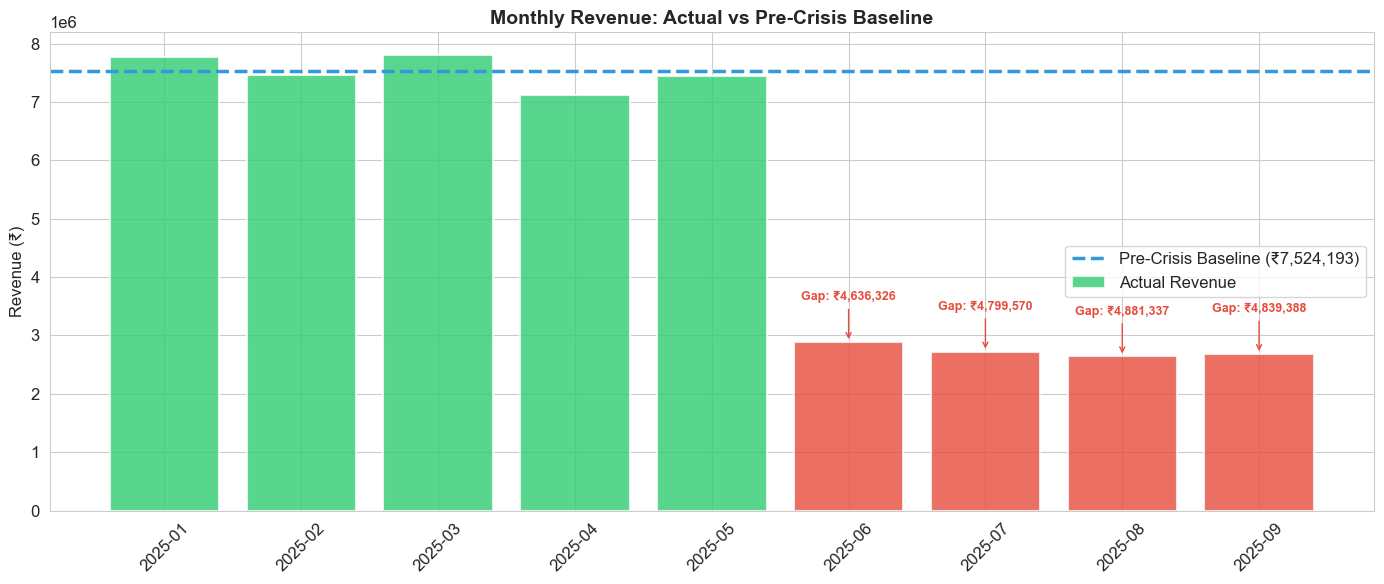


📉 Total Revenue Gap (Crisis Period): ₹19,156,620


In [4]:
# --- Actual vs Expected Revenue ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(monthly_revenue['month_str'], monthly_revenue['total_amount'],
       color=[PRE_COLOR if m <= 5 else CRISIS_COLOR for m in monthly_revenue['month_num']],
       edgecolor='white', linewidth=1.5, label='Actual Revenue', alpha=0.8)

ax.axhline(pre_monthly_avg, color=EXPECTED_COLOR, linestyle='--', linewidth=2.5,
           label=f'Pre-Crisis Baseline (₹{pre_monthly_avg:,.0f})')

# Annotate gap for crisis months
for _, row in monthly_revenue[monthly_revenue['month_num'] > 5].iterrows():
    if row['revenue_gap'] > 0:
        ax.annotate(f'Gap: ₹{row["revenue_gap"]:,.0f}',
                    xy=(row['month_str'], row['total_amount']),
                    xytext=(0, 30), textcoords='offset points',
                    ha='center', fontsize=9, fontweight='bold', color=CRISIS_COLOR,
                    arrowprops=dict(arrowstyle='->', color=CRISIS_COLOR))

ax.set_title('Monthly Revenue: Actual vs Pre-Crisis Baseline', fontsize=14, fontweight='bold')
ax.set_ylabel('Revenue (₹)')
ax.legend(fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

total_gap = monthly_revenue[monthly_revenue['month_num'] > 5]['revenue_gap'].sum()
print(f'\n📉 Total Revenue Gap (Crisis Period): ₹{total_gap:,.0f}')

---
# ❌ Section 2: Cost of Cancelled Orders

Cancelled orders represent **lost revenue** plus **wasted operational costs**. Since we don't have price data for cancelled orders, we estimate using the average order value from successful orders.

In [5]:
# Calculate cancellation costs
monthly_cancels = orders.groupby('month').agg(
    total_orders=('order_id', 'count'),
    cancelled=('is_cancelled_flag', 'sum')
).reset_index()
monthly_cancels['month_str'] = monthly_cancels['month'].astype(str)
monthly_cancels['cancel_rate'] = (monthly_cancels['cancelled'] / monthly_cancels['total_orders'] * 100).round(1)

# Average order value from successful orders
avg_order_value = successful_orders['total_amount'].mean()
avg_delivery_fee = successful_orders['delivery_fee'].mean()

monthly_cancels['estimated_revenue_loss'] = monthly_cancels['cancelled'] * avg_order_value
monthly_cancels['estimated_delivery_cost'] = monthly_cancels['cancelled'] * avg_delivery_fee  # Partial cost incurred

print(f'Average Order Value (successful): ₹{avg_order_value:.2f}')
print(f'Average Delivery Fee: ₹{avg_delivery_fee:.2f}')
print(f'\nMonthly Cancellation Summary:')
monthly_cancels[['month_str', 'total_orders', 'cancelled', 'cancel_rate', 'estimated_revenue_loss']].to_string(index=False)
monthly_cancels

Average Order Value (successful): ₹351.75
Average Delivery Fee: ₹32.49

Monthly Cancellation Summary:


,month,total_orders,cancelled,month_str,cancel_rate,estimated_revenue_loss,estimated_delivery_cost
0,2025-01,23539,1463,2025-01,6.2,514616.831561,47532.143661
1,2025-02,22667,1395,2025-02,6.2,490697.525651,45322.857421
2,2025-03,23543,1410,2025-03,6.0,495973.843131,45810.199974
3,2025-04,21466,1256,2025-04,5.9,441803.650335,40806.816431
4,2025-05,22591,1370,2025-05,6.1,481903.663184,44510.619833
5,2025-06,9293,1074,2025-06,11.6,377784.331576,34893.726789
6,2025-07,8818,1050,2025-07,11.9,369342.223608,34113.978704
7,2025-08,8555,1070,2025-08,12.5,376377.313582,34763.768775
8,2025-09,8694,1024,2025-09,11.8,360196.606643,33269.251612


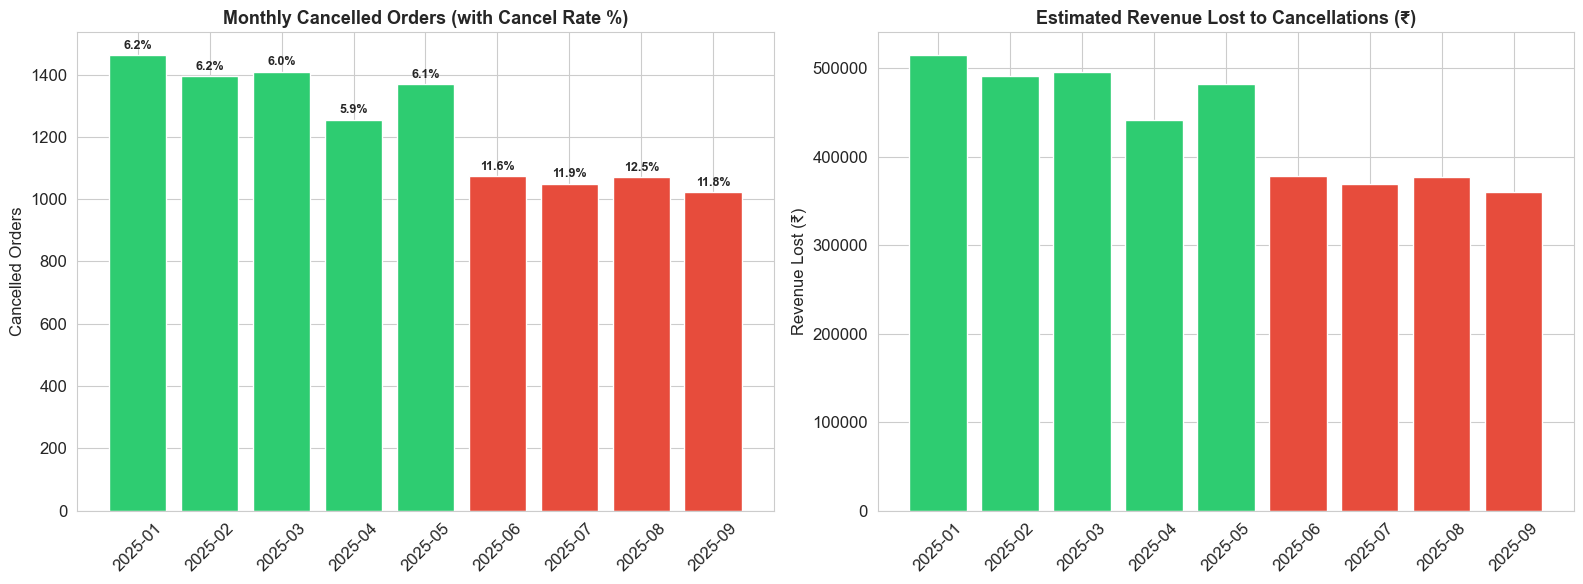


📉 Total Revenue Lost to Cancellations (All Time): ₹3,908,696
📉 Revenue Lost to Cancellations (Crisis Only): ₹1,483,700


In [6]:
# --- Cancellation Cost Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Monthly cancellations
axes[0].bar(monthly_cancels['month_str'], monthly_cancels['cancelled'],
            color=[PRE_COLOR if i < 5 else CRISIS_COLOR for i in range(len(monthly_cancels))], edgecolor='white')
for i, row in monthly_cancels.iterrows():
    axes[0].text(i, row['cancelled'] + 20, f'{row["cancel_rate"]}%',
                 ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Monthly Cancelled Orders (with Cancel Rate %)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Cancelled Orders')
axes[0].tick_params(axis='x', rotation=45)

# Revenue lost to cancellations
axes[1].bar(monthly_cancels['month_str'], monthly_cancels['estimated_revenue_loss'],
            color=[PRE_COLOR if i < 5 else CRISIS_COLOR for i in range(len(monthly_cancels))], edgecolor='white')
axes[1].set_title('Estimated Revenue Lost to Cancellations (₹)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Revenue Lost (₹)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

total_cancel_loss = monthly_cancels['estimated_revenue_loss'].sum()
crisis_cancel_loss = monthly_cancels[monthly_cancels['month'].apply(lambda x: x.month) > 5]['estimated_revenue_loss'].sum()
print(f'\n📉 Total Revenue Lost to Cancellations (All Time): ₹{total_cancel_loss:,.0f}')
print(f'📉 Revenue Lost to Cancellations (Crisis Only): ₹{crisis_cancel_loss:,.0f}')

---
# 🚚 Section 3: Delivery Cost Inefficiencies

Late deliveries and delays incur hidden costs: customer compensation, partner overtime, and operational overhead.

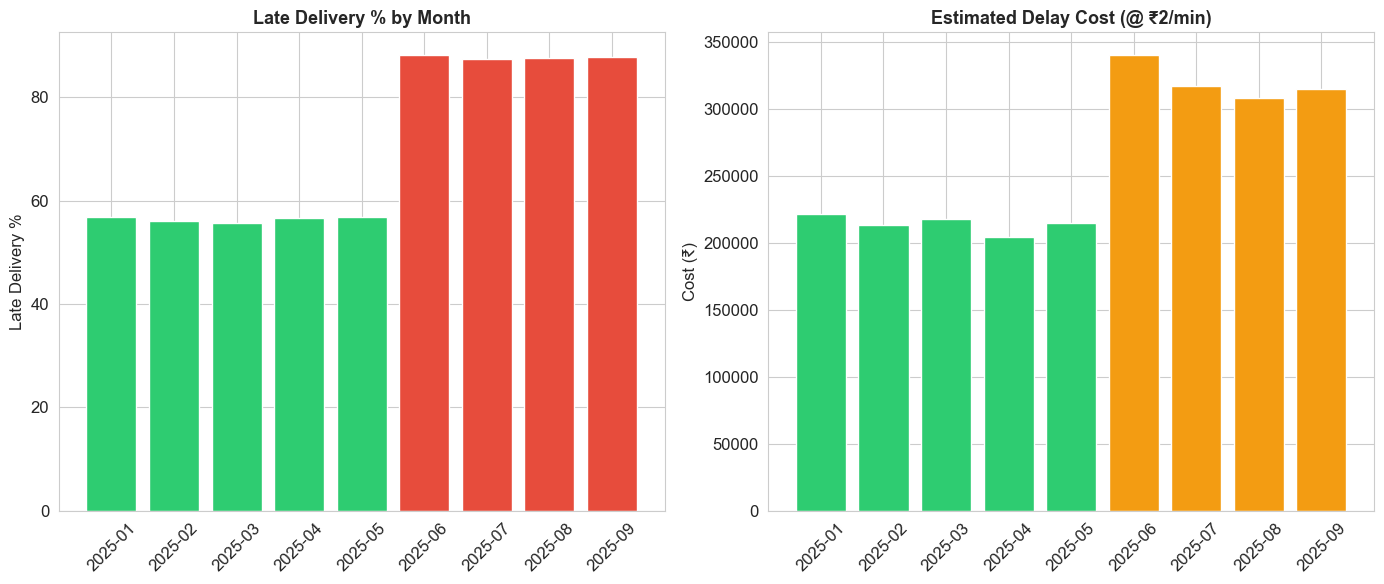


📉 Total Delay Cost (All Time): ₹2,351,368
📉 Delay Cost (Crisis Only): ₹1,279,934


In [7]:
# Delivery inefficiency metrics
del_with_period = delivery.merge(orders[['order_id', 'period', 'month']], on='order_id')

del_monthly = del_with_period.groupby('month').agg(
    total_deliveries=('order_id', 'count'),
    avg_delay=('delay_mins', 'mean'),
    late_orders=('delay_mins', lambda x: (x > 0).sum()),
    severely_late=('delay_mins', lambda x: (x > 15).sum()),
    total_excess_mins=('delay_mins', lambda x: x[x > 0].sum())
).reset_index()
del_monthly['month_str'] = del_monthly['month'].astype(str)
del_monthly['late_pct'] = (del_monthly['late_orders'] / del_monthly['total_deliveries'] * 100).round(1)

# Estimated cost per minute of delay (operational overhead)
COST_PER_DELAY_MIN = 2  # ₹2 per minute of delay (partner time + fuel)
del_monthly['delay_cost'] = del_monthly['total_excess_mins'] * COST_PER_DELAY_MIN

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Late order trend
axes[0].bar(del_monthly['month_str'], del_monthly['late_pct'],
            color=[PRE_COLOR if i < 5 else CRISIS_COLOR for i in range(len(del_monthly))], edgecolor='white')
axes[0].set_title('Late Delivery % by Month', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Late Delivery %')
axes[0].tick_params(axis='x', rotation=45)

# Delay cost
axes[1].bar(del_monthly['month_str'], del_monthly['delay_cost'],
            color=[PRE_COLOR if i < 5 else GAP_COLOR for i in range(len(del_monthly))], edgecolor='white')
axes[1].set_title(f'Estimated Delay Cost (@ ₹{COST_PER_DELAY_MIN}/min)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Cost (₹)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

total_delay_cost = del_monthly['delay_cost'].sum()
crisis_delay_cost = del_monthly[del_monthly['month'].apply(lambda x: x.month) > 5]['delay_cost'].sum()
print(f'\n📉 Total Delay Cost (All Time): ₹{total_delay_cost:,.0f}')
print(f'📉 Delay Cost (Crisis Only): ₹{crisis_delay_cost:,.0f}')

---
# 👥 Section 4: Customer Lifetime Value (CLV) Loss

Lost customers don't just mean one lost order — they represent months/years of future revenue.

In [8]:
# Calculate CLV for churned customers
pre_custs = set(pre['customer_id'].unique())
crisis_custs = set(crisis['customer_id'].unique())
churned = pre_custs - crisis_custs

# CLV estimation based on ordering history
churned_profiles = orders[orders['customer_id'].isin(churned)].groupby('customer_id').agg(
    total_orders=('order_id', 'count'),
    total_spent=('total_amount', 'sum'),
    months_active=('month', 'nunique')
).reset_index()

churned_profiles['monthly_value'] = churned_profiles['total_spent'] / churned_profiles['months_active']
churned_profiles['projected_12mo_clv'] = churned_profiles['monthly_value'] * 12

total_clv_loss = churned_profiles['projected_12mo_clv'].sum()
avg_clv = churned_profiles['projected_12mo_clv'].mean()

# Segment by value
churned_profiles['segment'] = pd.qcut(churned_profiles['total_spent'], q=4,
    labels=['Low', 'Medium', 'High', 'Premium'])

clv_by_segment = churned_profiles.groupby('segment').agg(
    customer_count=('customer_id', 'count'),
    total_clv_12mo=('projected_12mo_clv', 'sum'),
    avg_clv_12mo=('projected_12mo_clv', 'mean')
).round(0).astype(int)

print(f'Total Churned Customers: {len(churned):,}')
print(f'Total 12-Month CLV at Risk: ₹{total_clv_loss:,.0f}')
print(f'Avg CLV per Customer: ₹{avg_clv:,.0f}')
print(f'\n--- CLV by Segment ---')
clv_by_segment

Total Churned Customers: 72,768
Total 12-Month CLV at Risk: ₹306,148,249
Avg CLV per Customer: ₹4,207

--- CLV by Segment ---


,customer_count,total_clv_12mo,avg_clv_12mo
segment,,,
Low,18194,40442061,2223
Medium,18192,69246470,3806
High,18191,90546385,4978
Premium,18191,105913333,5822


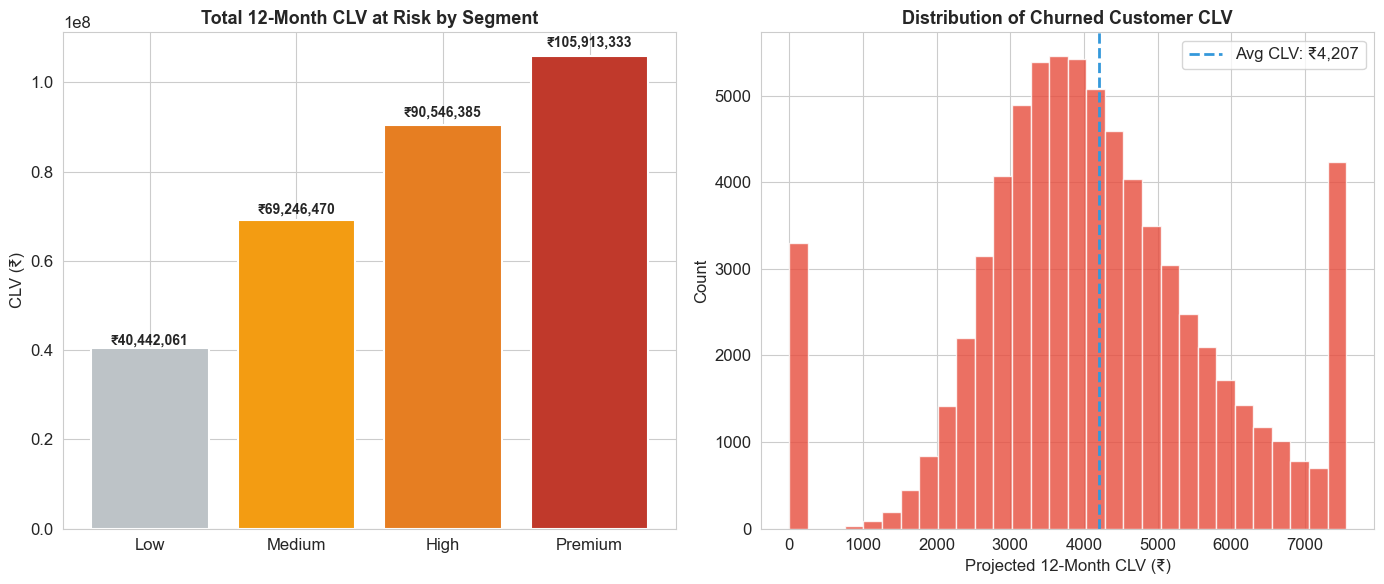

In [9]:
# --- CLV Loss Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors_seg = ['#bdc3c7', '#f39c12', '#e67e22', '#c0392b']

bars = axes[0].bar(clv_by_segment.index, clv_by_segment['total_clv_12mo'],
                   color=colors_seg, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, clv_by_segment['total_clv_12mo']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                 f'₹{val:,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Total 12-Month CLV at Risk by Segment', fontsize=13, fontweight='bold')
axes[0].set_ylabel('CLV (₹)')

axes[1].hist(churned_profiles['projected_12mo_clv'].clip(upper=churned_profiles['projected_12mo_clv'].quantile(0.95)),
             bins=30, color=CRISIS_COLOR, edgecolor='white', alpha=0.8)
axes[1].axvline(avg_clv, color=EXPECTED_COLOR, linestyle='--', linewidth=2, label=f'Avg CLV: ₹{avg_clv:,.0f}')
axes[1].set_title('Distribution of Churned Customer CLV', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Projected 12-Month CLV (₹)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

---
# 🍽️ Section 5: Revenue Lost from Churned Restaurants

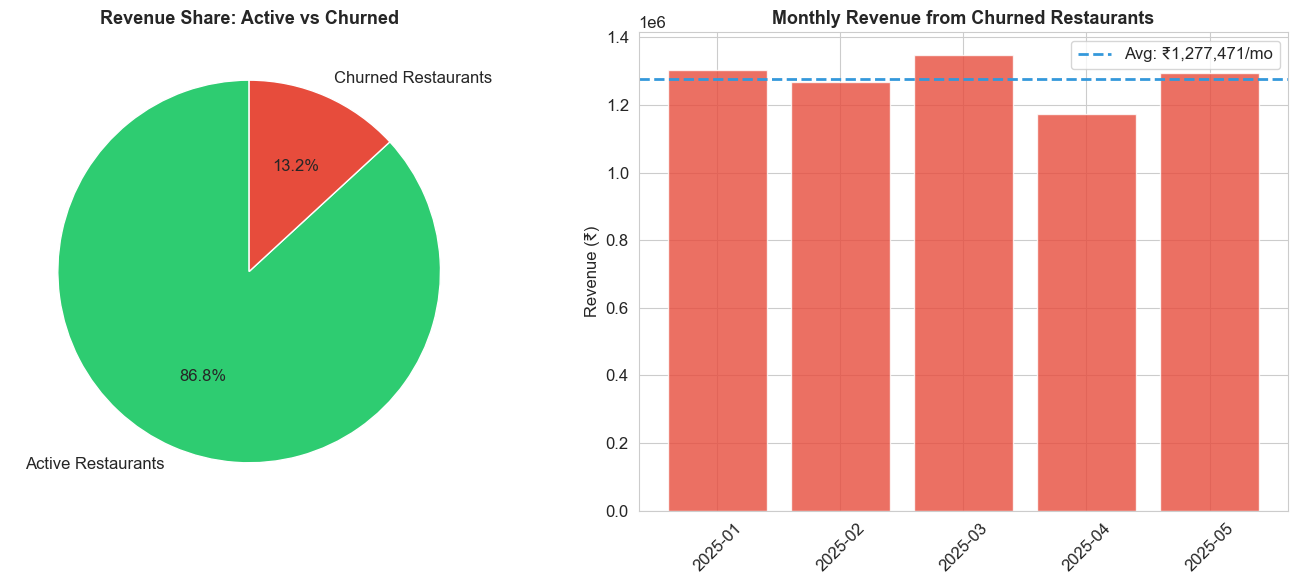


Total revenue from churned restaurants: ₹6,387,356
Projected annual loss if not recovered: ₹15,329,655


In [10]:
# Revenue from churned restaurants
rest_orders = orders.merge(restaurant[['restaurant_id', 'is_active', 'restaurant_name']], on='restaurant_id')

rest_rev = rest_orders.groupby('is_active').agg(
    total_revenue=('total_amount', 'sum'),
    total_orders=('order_id', 'count'),
    unique_restaurants=('restaurant_id', 'nunique')
).round(0).astype(int)

# Monthly revenue from churned restaurants (shows what they used to bring in)
churned_rest_monthly = rest_orders[rest_orders['is_active'] == 'N'].groupby('month')['total_amount'].sum().reset_index()
churned_rest_monthly['month_str'] = churned_rest_monthly['month'].astype(str)

# Project future loss
churned_monthly_avg = churned_rest_monthly['total_amount'].mean()
projected_annual_loss = churned_monthly_avg * 12

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Revenue split
labels = ['Active Restaurants', 'Churned Restaurants']
vals = [rest_rev.loc['Y', 'total_revenue'], rest_rev.loc['N', 'total_revenue']]
axes[0].pie(vals, labels=labels, colors=[PRE_COLOR, CRISIS_COLOR],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Revenue Share: Active vs Churned', fontsize=13, fontweight='bold')

# Monthly trend
axes[1].bar(churned_rest_monthly['month_str'], churned_rest_monthly['total_amount'],
            color=CRISIS_COLOR, edgecolor='white', alpha=0.8)
axes[1].axhline(churned_monthly_avg, color=EXPECTED_COLOR, linestyle='--', linewidth=2,
                label=f'Avg: ₹{churned_monthly_avg:,.0f}/mo')
axes[1].set_title('Monthly Revenue from Churned Restaurants', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Revenue (₹)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'\nTotal revenue from churned restaurants: ₹{rest_rev.loc["N", "total_revenue"]:,}')
print(f'Projected annual loss if not recovered: ₹{projected_annual_loss:,.0f}')

---
# 📊 Section 6: Total Financial Damage Summary

In [11]:
# --- Consolidated Loss Summary ---
losses = {
    'Revenue Gap\n(Crisis vs Baseline)': total_gap,
    'Cancellation\nRevenue Loss': crisis_cancel_loss,
    'Delivery Delay\nCosts': crisis_delay_cost,
    'Customer CLV\nAt Risk (12mo)': total_clv_loss,
    'Restaurant\nAnnual Risk': projected_annual_loss
}

# The total should not double-count: CLV and Restaurant Risk are projections, not actual losses
actual_losses = total_gap + crisis_cancel_loss + crisis_delay_cost
projected_losses = total_clv_loss + projected_annual_loss

print('╔══════════════════════════════════════════════════════════════╗')
print('║           TOTAL FINANCIAL DAMAGE REPORT                    ║')
print('╠══════════════════════════════════════════════════════════════╣')
print('║ ACTUAL LOSSES (Crisis Period)                              ║')
print(f'║   Revenue Gap (vs Baseline):           ₹{total_gap:>15,.0f}  ║')
print(f'║   Cancellation Revenue Loss:           ₹{crisis_cancel_loss:>15,.0f}  ║')
print(f'║   Delivery Delay Costs:                ₹{crisis_delay_cost:>15,.0f}  ║')
print(f'║   ─────────────────────────────────────────────────────   ║')
print(f'║   TOTAL ACTUAL LOSSES:                 ₹{actual_losses:>15,.0f}  ║')
print('║                                                            ║')
print('║ PROJECTED FUTURE LOSSES (If No Recovery)                   ║')
print(f'║   Customer CLV at Risk (12mo):         ₹{total_clv_loss:>15,.0f}  ║')
print(f'║   Restaurant Revenue at Risk (Annual): ₹{projected_annual_loss:>15,.0f}  ║')
print(f'║   ─────────────────────────────────────────────────────   ║')
print(f'║   TOTAL PROJECTED LOSSES:              ₹{projected_losses:>15,.0f}  ║')
print('║                                                            ║')
print(f'║   ══════════════════════════════════════════════════════   ║')
print(f'║   TOTAL DAMAGE (Actual + Projected):   ₹{actual_losses + projected_losses:>15,.0f}  ║')
print('╚══════════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════════╗
║           TOTAL FINANCIAL DAMAGE REPORT                    ║
╠══════════════════════════════════════════════════════════════╣
║ ACTUAL LOSSES (Crisis Period)                              ║
║   Revenue Gap (vs Baseline):           ₹     19,156,620  ║
║   Cancellation Revenue Loss:           ₹      1,483,700  ║
║   Delivery Delay Costs:                ₹      1,279,934  ║
║   ─────────────────────────────────────────────────────   ║
║   TOTAL ACTUAL LOSSES:                 ₹     21,920,255  ║
║                                                            ║
║ PROJECTED FUTURE LOSSES (If No Recovery)                   ║
║   Customer CLV at Risk (12mo):         ₹    306,148,249  ║
║   Restaurant Revenue at Risk (Annual): ₹     15,329,655  ║
║   ─────────────────────────────────────────────────────   ║
║   TOTAL PROJECTED LOSSES:              ₹    321,477,904  ║
║                                                            ║
║   

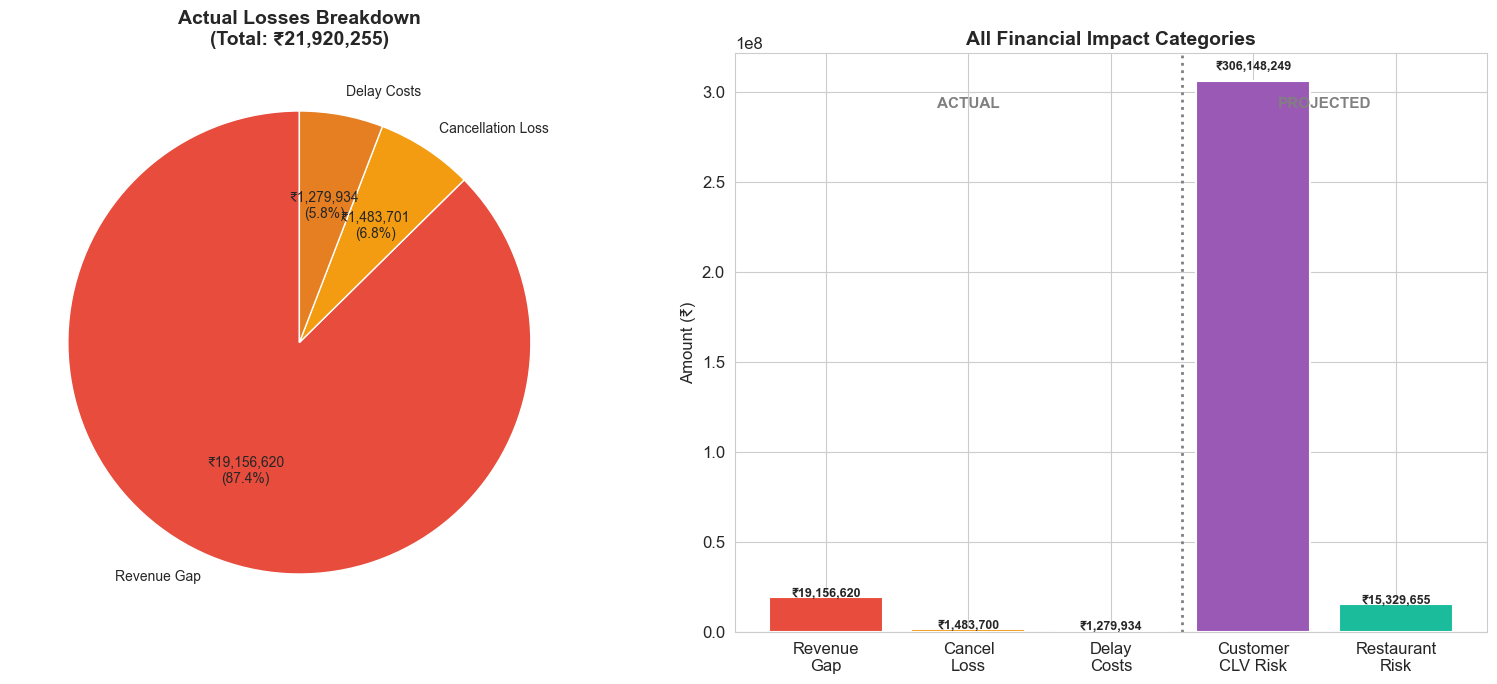

In [12]:
# --- Visual Damage Dashboard ---
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Actual losses breakdown
actual_labels = ['Revenue Gap', 'Cancellation Loss', 'Delay Costs']
actual_vals = [total_gap, crisis_cancel_loss, crisis_delay_cost]
colors_actual = [CRISIS_COLOR, GAP_COLOR, '#e67e22']
wedges, texts, autotexts = axes[0].pie(actual_vals, labels=actual_labels, colors=colors_actual,
    autopct=lambda pct: f'₹{pct/100*sum(actual_vals):,.0f}\n({pct:.1f}%)',
    startangle=90, textprops={'fontsize': 10})
axes[0].set_title(f'Actual Losses Breakdown\n(Total: ₹{actual_losses:,.0f})', fontsize=14, fontweight='bold')

# All losses comparison
all_labels = ['Revenue\nGap', 'Cancel\nLoss', 'Delay\nCosts', 'Customer\nCLV Risk', 'Restaurant\nRisk']
all_vals = [total_gap, crisis_cancel_loss, crisis_delay_cost, total_clv_loss, projected_annual_loss]
all_colors = [CRISIS_COLOR, GAP_COLOR, '#e67e22', '#9b59b6', '#1abc9c']
bars = axes[1].bar(all_labels, all_vals, color=all_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, all_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                 f'₹{val:,.0f}', ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('All Financial Impact Categories', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Amount (₹)')

# Add divider between actual and projected
axes[1].axvline(2.5, color='gray', linestyle=':', linewidth=2)
axes[1].text(1, max(all_vals) * 0.95, 'ACTUAL', ha='center', fontsize=11, fontweight='bold', color='gray')
axes[1].text(3.5, max(all_vals) * 0.95, 'PROJECTED', ha='center', fontsize=11, fontweight='bold', color='gray')

plt.tight_layout()
plt.show()

## 📋 Financial Impact — Key Conclusions

### Actual Crisis Losses
| Category | Description | Impact |
|----------|-------------|--------|
| **Revenue Gap** | Difference between actual and expected revenue during crisis months | Direct revenue loss |
| **Cancellation Loss** | Revenue from orders that were placed but cancelled | Wasted customer intent + operational costs |
| **Delivery Delay Costs** | Partner time, fuel, and overhead from delays | Operational inefficiency |

### Projected Losses (If No Recovery Action Taken)
| Category | Description | Time Horizon |
|----------|-------------|-------------|
| **Customer CLV at Risk** | Lifetime value of churned customers if permanently lost | 12 months |
| **Restaurant Revenue Risk** | Revenue from restaurants that have left the platform | Annual |

### 🎯 Bottom Line
- The **actual crisis losses** represent immediate damage already incurred
- The **projected losses** represent the long-term cost of inaction
- **Every month without recovery action compounds the damage** — the CLV loss grows as customer re-engagement becomes harder
- The Recovery Strategies notebook (Notebook 5) outlines how to address each category